<h1> Import

In [1]:

from masterthesis.data.loaders import load_cell_dataframe
from masterthesis.data.datasets import build_env_dict
from masterthesis.data.preprocessing import preprocess_env_data
from masterthesis.data.dataset_object import make_environment_dataset

from masterthesis.algorithms.notears import run_notears
from masterthesis.algorithms.pc import run_pc
from masterthesis.algorithms.dotears import run_dotears

from masterthesis.experiments import run_algorithms
from masterthesis.evaluation import load_all_dags, dag_frequency_matrix
from masterthesis.visualization import plot_dag_frequency_heatmap, save_graph_plot


<h1> Single Cell

<h2> Data

In [2]:
cell_df = load_cell_dataframe()
cell_df.head()


,CellID,CurrentData,VoltageData,TempData,StepIndex,CycleIndex,TimeData
0,GS3,0.0,4.197761,24.041702,9,1,0.0000
1,GS3,0.0,4.197635,23.955681,9,1,1.0003
2,GS3,0.0,4.197824,23.926302,9,1,2.0001
3,GS3,0.0,4.197635,23.979719,9,1,3.0004
4,GS3,0.0,4.197635,24.001940,9,1,4.0000


In [3]:
cols = ["CurrentData", "VoltageData", "TempData", "CycleIndex"]

groups = [[9, 11, 13, 15, 22], [10, 12], [14]] #[17, 18, 19, 20, 21]

env_df = build_env_dict(cell_df, cols, groups, sort_by="StepIndex")

<h3> Preprocessing (scaling+noise)

In [4]:
env_data = preprocess_env_data(
    env_df,
    scale=True,
    noise_std=0.1,
    seed=42,
)


<h3> Dataset

In [5]:
interventions = {
    0: [],     # observational environment
    1: [0],    # env1 intervenes on variable 2
    2: [0],    # env2 intervenes on variable 2
}
dataset = make_environment_dataset(env_data, interventions)

In [6]:
print(dataset.keys())
print(dataset['X'])
print(len(dataset['X']))

print(len(dataset['envs']))
print(dataset['interventions'])
print(len(dataset['interventions']))


dict_keys(['X', 'envs', 'interventions'])
[[ 0.27402908  1.79104683  1.42422154 -1.32464339]
 [ 0.20094233  1.78097703  1.38087453 -1.4002029 ]
 [ 0.17741023  1.85937054  1.12999283 -1.52351935]
 ...
 [ 2.13151611 -1.31037466 -0.55740441  1.62397332]
 [ 2.04387577 -1.33202803 -0.58684064  1.37043971]
 [ 1.91603967 -1.34224006 -0.43766552  1.5624971 ]]
2452952
3
{0: [], 1: [0], 2: [0]}
3


<h2> PC

In [7]:
dag_pc = run_pc(dataset)
print(dag_pc)

  0%|          | 0/4 [00:00<?, ?it/s]

[[0 1 1 1]
 [1 0 1 1]
 [1 1 0 1]
 [1 1 1 0]]


<h2> No-Tears

In [8]:
dag_notears = run_notears(dataset)
print(dag_notears)

100%|██████████| 20/20 [00:20<00:00,  1.05s/it]

[[0 0 0 0]
 [1 0 1 1]
 [0 0 0 0]
 [1 0 1 0]]


<h2> Third alg-Do Tears

In [9]:
dag_dotears = run_dotears(dataset)
print(dag_dotears)

0 h = 1.0080274840749688
1 h = 0.10622757352970513
2 h = 0.021435732023668663
3 h = 0.004156479580920802
4 h = 0.0008742214694033024
5 h = 0.00018731077764044812
6 h = 4.030608982930062e-05
7 h = 8.680639066227513e-06
[[0 0 0 0]
 [0 0 0 1]
 [0 0 0 0]
 [0 0 0 0]]


<h2> Third alg- GIES

<h2> Compare/Results?

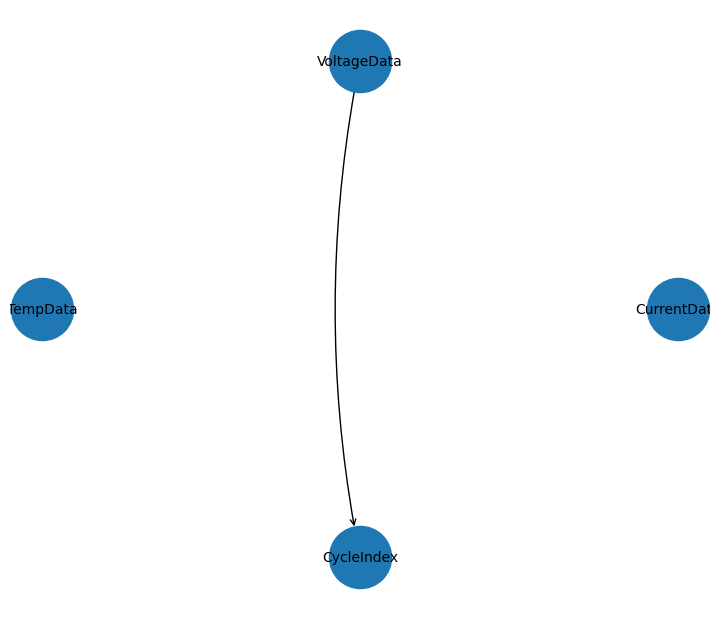

In [10]:
save_graph_plot(cols, dag_dotears) 